In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings('ignore')

# constants
#RSEED = 10

1. Data Import

In [2]:
# import data from CSV
df = pd.read_csv("data/kickstarter_projects.csv")

In [3]:

# check import
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [4]:
df.columns

Index(['ID', 'Name', 'Category', 'Subcategory', 'Country', 'Launched',
       'Deadline', 'Goal', 'Pledged', 'Backers', 'State'],
      dtype='object')

In [5]:
# # OPTIONAL: Rename columns for clarity


    # "goal": "Amount Requested",
    # "pledged": "Money Raised",
    # "funded_ratio": "Funding Achieved (%)",
    # "backers": "Number of Supporters",
    # "launched": "Launch Date",
    # "deadline": "Deadline",
    # "launch_year": "Launch Year",
    # "launch_month": "Launch Month",
    # "launch_dayofweek": "Launch Day (Mon–Sun)",
    # "duration_days": "Campaign Length (Days)",
    # "name_length": "Title Length (Characters)",
    # "name_word_count": "Title Length (Words)",
    # "category": "Main Category",
    # "subcategory": "Subcategory",
    # "country": "Country",
    # "currency": "Currency Used",
    # "is_success": "Was the Project Successful?"

df.columns = df.columns.str.lower()
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


1.1 Data Check

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


1.2 Statistcal Summary Check

In [7]:
df.describe()

,id,goal,pledged,backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


2 EDA
General Feature Exploration

In [8]:
# 2) Quick look
print("Shape:", df.shape)
display(df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
# Rows 378661, 
# columns 11
# it shows the data types and missing values for each column. we have object and int64 data types.

Shape: (374853, 11)


,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed



Dtypes:
 id              int64
name           object
category       object
subcategory    object
country        object
launched       object
deadline       object
goal            int64
pledged         int64
backers         int64
state          object
dtype: object

Missing values:
 id             0
name           0
category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
state          0
dtype: int64


In [9]:
df['state'].value_counts()

state
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


# Data cleaning and feature engineering

In [11]:
# 3) Parse dates + feature engineering
# Date -> datetime
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")

# Duration
df["duration_days"] = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)

df["funded_ratio"] = df["pledged"] / df["goal"]
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)
display(df[["goal", "pledged", "backers", "duration_days", "funded_ratio"]].describe())

,goal,pledged,backers,duration_days,funded_ratio
count,3.748530e+05,3.748530e+05,374853.000000,374853.000000,3.748510e+05
mean,4.586378e+04,9.121073e+03,106.690359,33.651440,inf
std,1.158778e+06,9.132054e+04,911.718520,12.814719,NaN
min,0.000000e+00,0.000000e+00,0.000000,0.005058,0.000000e+00
25%,2.000000e+03,3.100000e+01,2.000000,29.098044,4.566438e-03
50%,5.500000e+03,6.250000e+02,12.000000,29.690787,1.342857e-01
75%,1.600000e+04,4.051000e+03,57.000000,36.740370,1.065250e+00
max,1.663614e+08,2.033899e+07,219382.000000,91.962650,inf


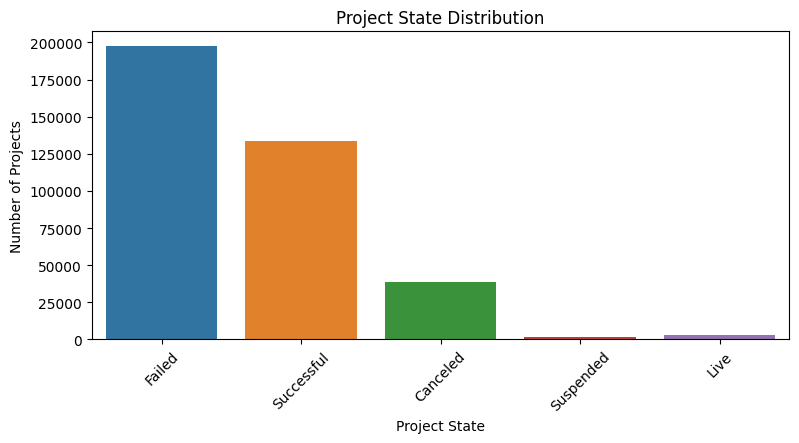

In [12]:
# A) Plotting the Project State Distribution
plt.subplots(figsize=(9,4), dpi=100)

sns.countplot(x="state",data=df)
plt.title("Project State Distribution")
plt.xlabel("Project State")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.show()

In [13]:
# 4) Feature engineering (best “value add” features)
df["duration_days"]    = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)     # To get the exact number of days each project ran.

# Date parts
df["launch_year"]      = df["launched"].dt.year         # This pulls/extract the year from the “Launched” date. Example: “2016-05-10” -> 2016
df["launch_month"]     = df["launched"].dt.month        # This pulls/extract the month number (1–12). Example: Oct -> 10
# df["launch_dayofweek"] = df["launched"].dt.dayofweek    # This pulls/extract the day of the week. Example: Friday = 4, counting from 0 = Monday

# Funding ratio (handle goal==0 safely)
df["funded_ratio"]     = df["pledged"] / df["goal"].replace(0, np.nan)                      # Helps model understand success likelihood
df["funded_ratio"]     = df["funded_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)    # If a project had goal = 0, division would produce ∞, Replace inf -> NaN -> 0, same with pledge

# Log transforms (helps skew)
# Avoid dominance of huge values (Pledged up to millions)
# Reduce skew and long tails
df["goal"]         = np.log1p(df["goal"]) 
df["pledged"]      = np.log1p(df["pledged"])
df["backers"]      = np.log1p(df["backers"])    

# Simple text features from Name
# df["name_length"]      = df["name"].astype(str).str.len()                 # Measures the total number of characters in the project title.
# df["name_word_count"]  = df["name"].astype(str).str.split().apply(len)    # Counts how many words appear in the title.

# Target variable
df = df[df["state"].str.lower() != "live"]
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)    # Need to remove live and suspend

# Virtualization

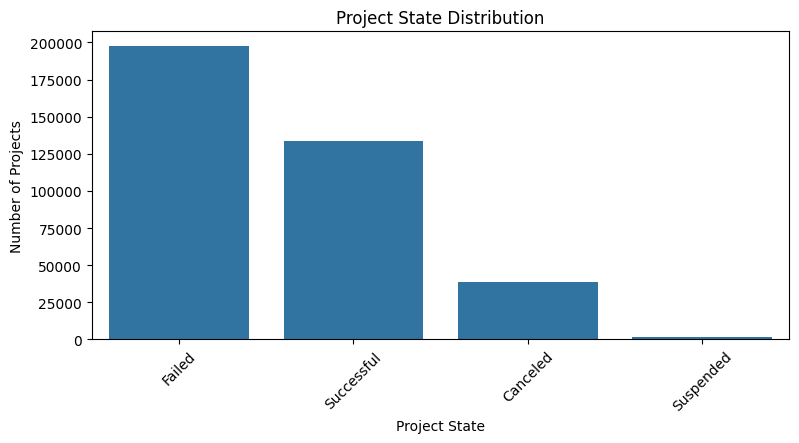

In [14]:
# A) Plotting the Project State Distribution
plt.subplots(figsize=(9,4), dpi=100)

sns.countplot(
    x="state",
    data=df,
    palette=["#1F77B4"]  # Corporate Blue for all bars
)
plt.title("Project State Distribution")
plt.xlabel("Project State")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Quick look

success_projects = df[df['state'] == 'Successful']['state'].count()     # This filters the dataframe to rows where state == “successful”,then counts how many.
fail_projects  = df[df['state'] == 'Failed']['state'].count()           # This filters the dataframe to rows where state == “failed”,then counts how many.
others_projects  = (
    df[df['state'] == 'Canceled']['state'].count() +
    df[df['state'] == 'Live']['state'].count() +
    df[df['state'] == 'Suspended']['state'].count())                    # This groups anything that isn’t clearly success or failure: "canceled", "live", "suspended"
	

print(f"Successful Projects: {success_projects}")
print(f"Failed Projects: {fail_projects}")
print(f"Other Projects: {others_projects}")

Successful Projects: 133851
Failed Projects: 197611
Other Projects: 40593


In [16]:
total=success_projects+fail_projects+others_projects
suc=success_projects/total
fail=fail_projects/total
other=others_projects/total

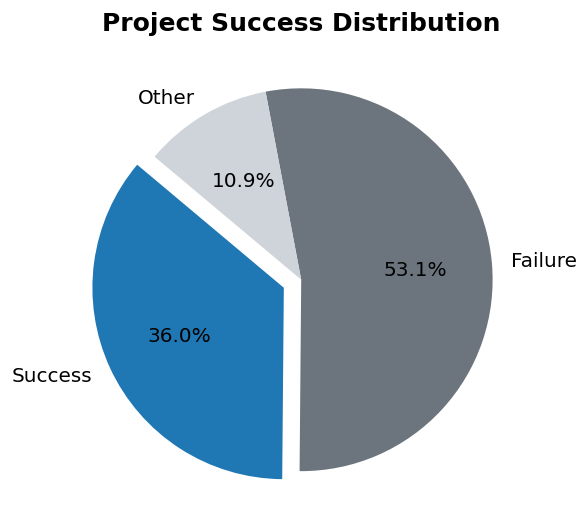

In [17]:
# Pie chart  


sizes = [suc, fail, other]
labels = ["Success", "Failure", "Other"]

# Corporate palette
colors = ["#1F77B4", "#6C757D", "#CED4DA"]   # Blue, Grey, Light Grey

explode = (0.1, 0, 0)

plt.figure(figsize=(5,5), dpi=120)

plt.pie(
    sizes,
    labels=labels,
    explode=explode,
    autopct='%1.1f%%',
    shadow=False,
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title("Project Success Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

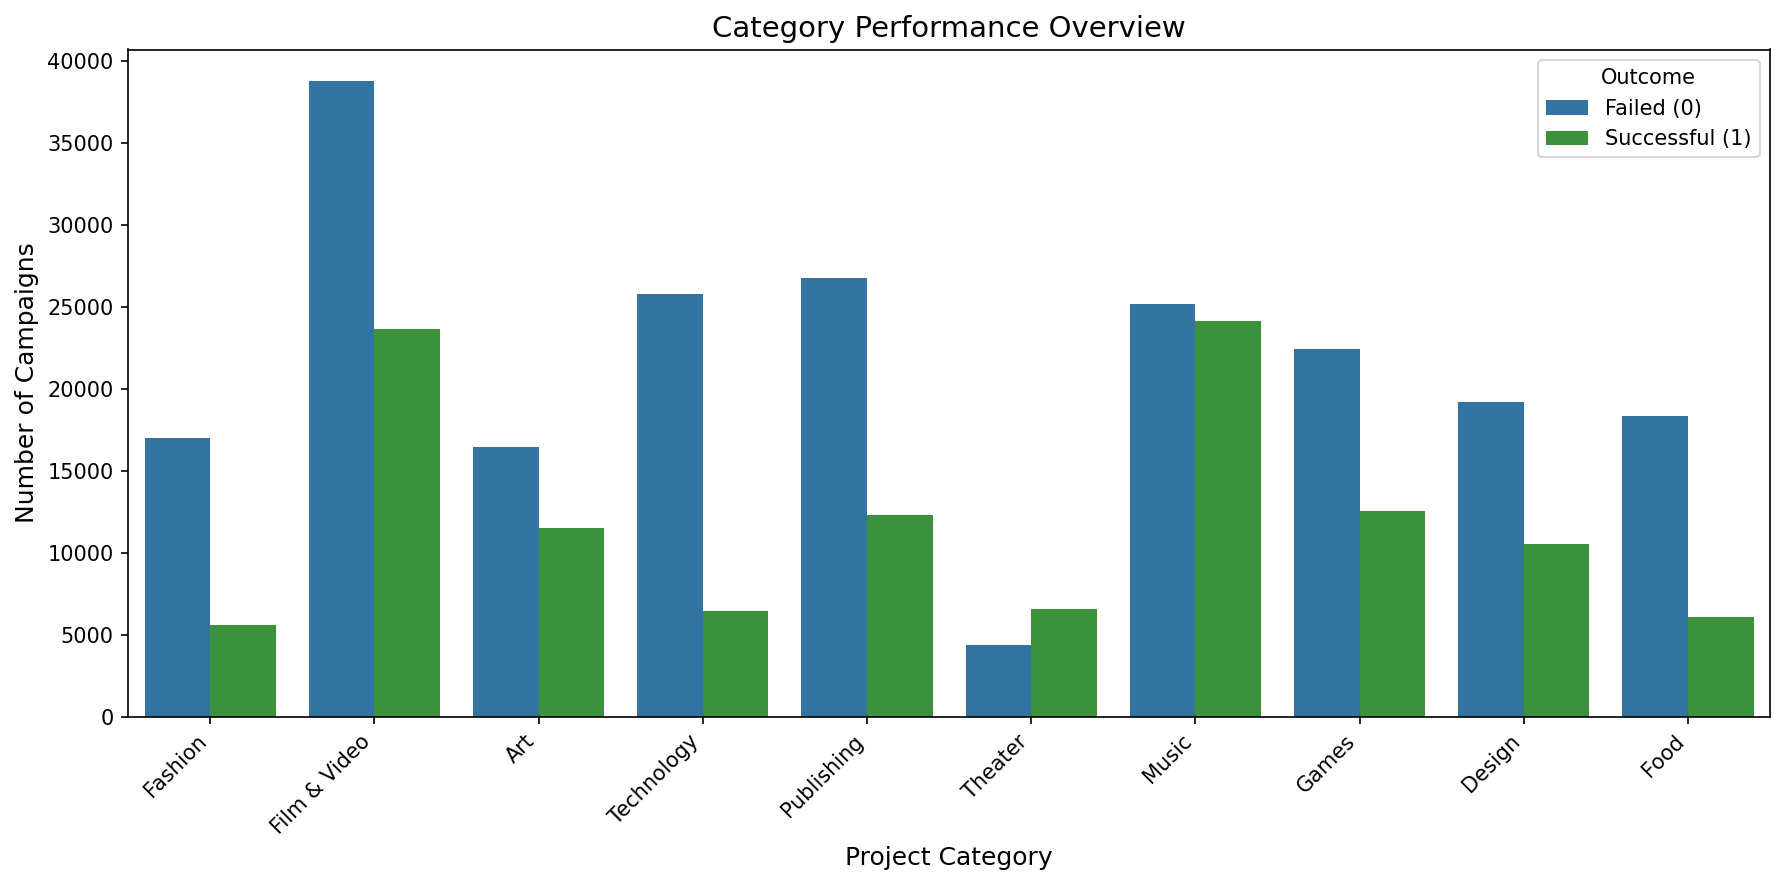

In [18]:
# B) Outcome distribution (Success vs Failed)
# Count categories
cat_counts = df["category"].value_counts()

# Select top N categories
top_n = 10
top_categories = cat_counts.head(top_n)
# Filter only top categories
df_top = df[df["category"].isin(top_categories.index)]

plt.figure(figsize=(12,6), dpi=150)
sns.countplot(
    data=df_top,
    x="category",
    hue="is_success",
    palette=["#1f77b4", "#2ca02c"]  # Fail = red, Success = green
)

plt.title("Category Performance Overview", fontsize=14)
plt.xlabel("Project Category", fontsize=12)
plt.ylabel("Number of Campaigns", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Outcome", labels=["Failed (0)", "Successful (1)"])
plt.tight_layout()
plt.show()

In [19]:
# # Count categories
# cat_counts = df["category"].value_counts()

# # Select top N categories
# top_n = 10
# top_categories = cat_counts.head(top_n)
# # Sum remaining into "Others"
# others = cat_counts.iloc[top_n:].sum()

# # Combine into one series
# final_counts = pd.concat([top_categories, pd.Series({"Others": others})])

# # Bar chart
# plt.figure(figsize=(10,6))
# plt.bar(final_counts.index, final_counts.values, color="#4682B4")

# # Titles & labels
# plt.title(f"Top {top_n} Success Kickstarter projects by Category", fontsize=14)
# plt.xlabel("Category", fontsize=12)
# plt.ylabel("Number of Projects", fontsize=12)

# # Rotate x-axis labels
# plt.xticks(rotation=45, ha="right", fontsize=10)

# # Add value labels on top of bars (optional but great for presentation)
# for i, v in enumerate(final_counts.values):
#     plt.text(i, v + (max(final_counts.values)*0.01), str(v), ha="center", fontsize=9)

# plt.tight_layout()
# plt.show()

In [20]:
# C) Success rate by category (top 15)
top_cats = df["category"].value_counts().head(15).index
success_by_cat = (
    df[df["category"].isin(top_cats)]
    .groupby("category")["is_success"]
    .mean()
    .sort_values(ascending=False)
)
# plt.figure(figsize=(9,4), dpi=100)
# success_by_cat.plot(kind="bar")
# plt.title("Success Rate by Category (Top 15)")
# plt.xlabel("Category")
# plt.ylabel("Success rate")
# plt.ylim(0, 1)
# plt.xticks(rotation=45)
# plt.show()

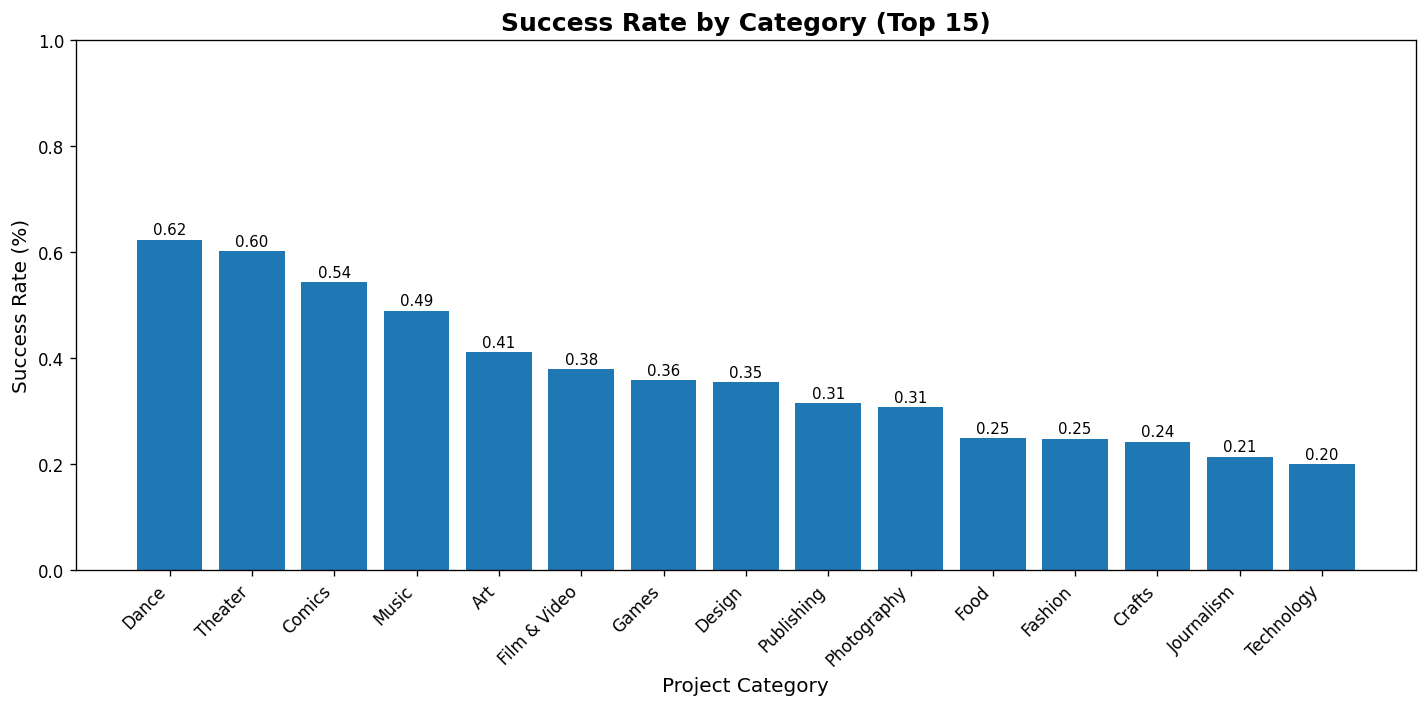

In [21]:
# C) Success rate by Category (Top 15 by volume)

plt.figure(figsize=(12,6), dpi=120)

bars = plt.bar(
    success_by_cat.index,
    success_by_cat.values,
    color="#1f77b4"  # professional blue
)

# Title & labels
plt.title("Success Rate by Category (Top 15)", fontsize=15, fontweight="bold")
plt.xlabel("Project Category", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right", fontsize=10)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [22]:
#same by country
df_successfull=df[df["state"] == "Successful"]
dtf_s = df_successfull["country"].value_counts()
dtf_cat=df["country"].value_counts()
dtf_perc = dtf_s/dtf_cat
dtf_perc


country
Australia         0.258721
Austria           0.183849
Belgium           0.251240
Canada            0.282686
Denmark           0.328168
France            0.314513
Germany           0.228760
Hong Kong         0.370497
Ireland           0.258750
Italy             0.156674
Japan             0.225806
Luxembourg        0.311475
Mexico            0.240729
Netherlands       0.217790
New Zealand       0.311978
Norway            0.231429
Singapore         0.337761
Spain             0.221223
Sweden            0.293034
Switzerland       0.250670
United Kingdom    0.361374
United States     0.375755
Name: count, dtype: float64

In [23]:
dtf_perc = dtf_perc.sort_values(ascending=False)

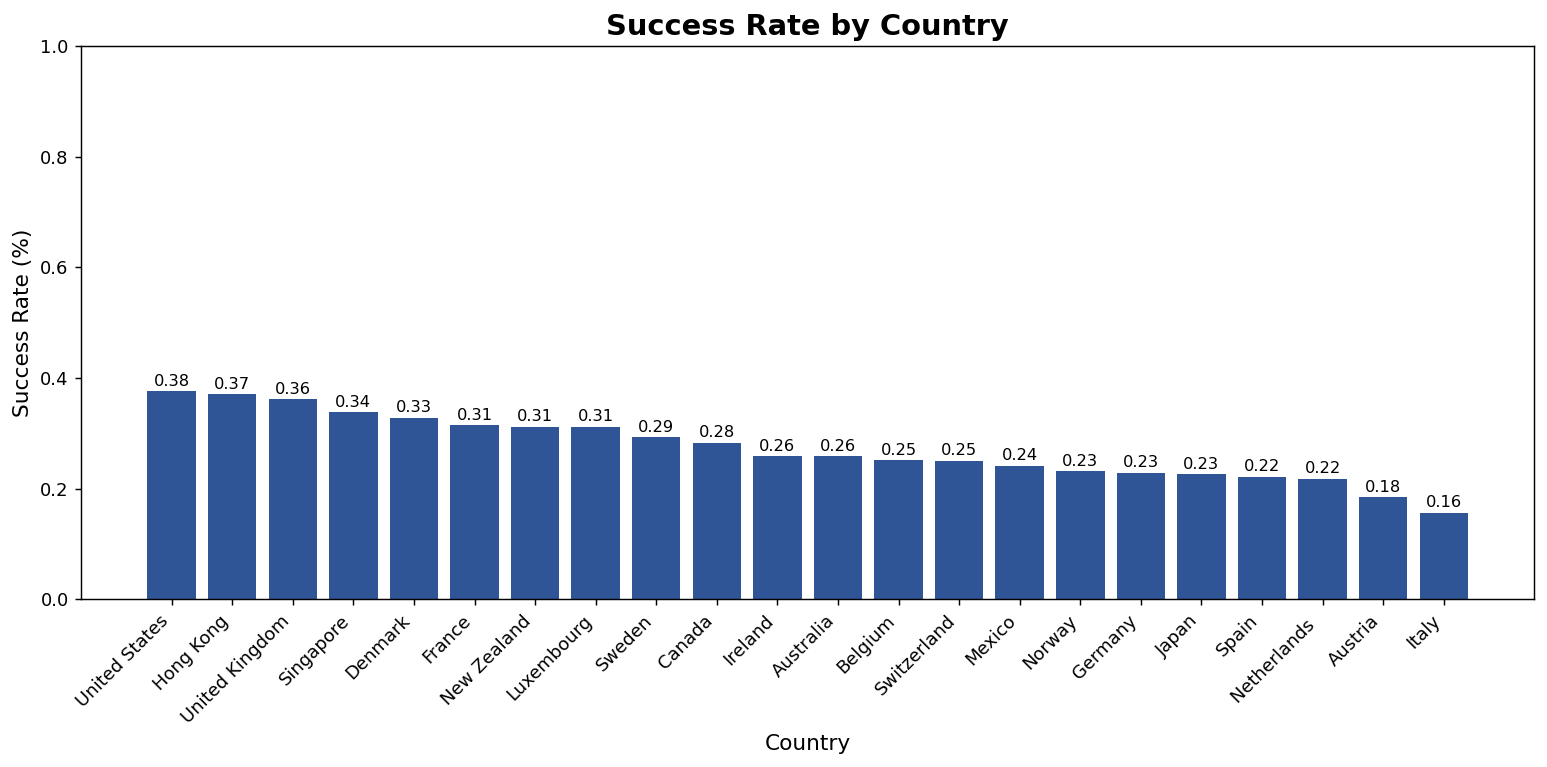

In [24]:
import matplotlib.pyplot as plt

# Sort for better visual
dtf_perc = dtf_perc.sort_values(ascending=False)

plt.figure(figsize=(12,6), dpi=130)

plt.bar(
    dtf_perc.index,
    dtf_perc.values,
    color="#2F5597"   # Deep corporate blue
)

# Title & axis labels
plt.title("Success Rate by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)

# Format y-axis to show percentage
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

# Add percentage labels above bars
for i, v in enumerate(dtf_perc.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

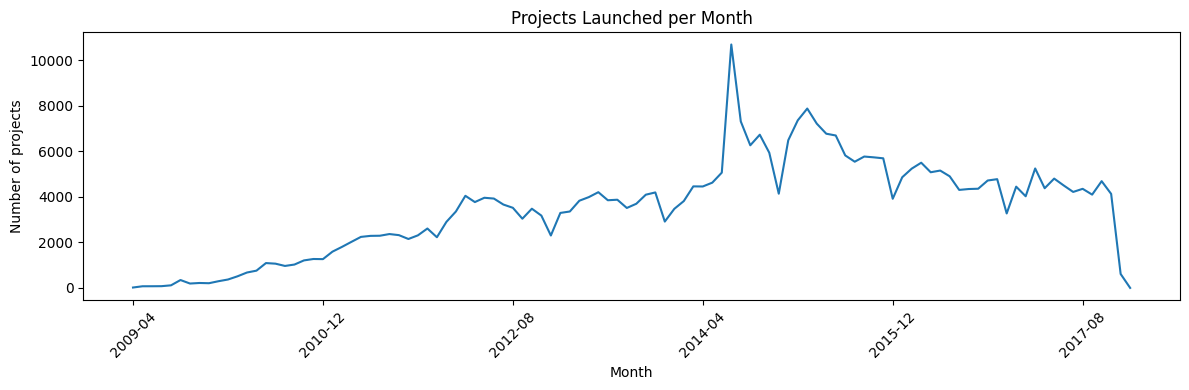

In [25]:
# D) Projects launched over time (monthly)
df["launch_ym"] = df["launched"].dt.to_period("M").astype(str)
monthly_projects = df.dropna(subset=["launched"]).groupby("launch_ym").size()

plt.figure(figsize=(12,4))
monthly_projects.plot()
plt.title("Projects Launched per Month")
plt.xlabel("Month")
plt.ylabel("Number of projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

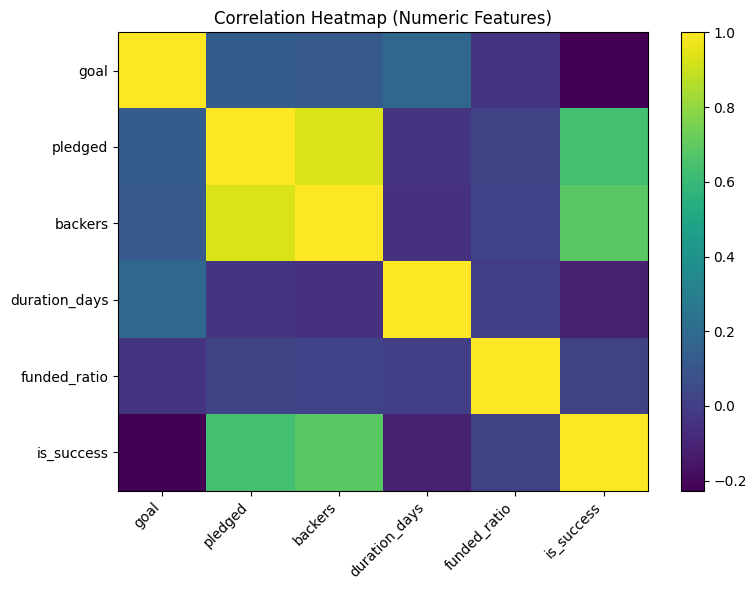

In [26]:
# G) Correlation heatmap (numeric features)
num_cols = ["goal", "pledged", "backers", "duration_days", "funded_ratio", "is_success"]
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6), dpi=100)
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

In [27]:
# (Optional) Final “model-ready” feature table preview
# -------------------------------------------------
feature_cols = [
    "category","subcategory","country",
    "duration_days","launch_year","launch_month",
    "goal","pledged","backers",
    "funded_ratio",
    "is_success"
]                                           #  "launch_dayofweek""name_length","name_word_count" <--- not included??
display(df[feature_cols].head())

,category,subcategory,country,duration_days,launch_year,launch_month,goal,pledged,backers,funded_ratio,is_success
0,Fashion,Fashion,United States,39.123056,2009,4,6.908755,6.439350,3.433987,0.625000,0
1,Film & Video,Shorts,United States,87.994525,2009,4,11.289794,3.135494,1.386294,0.000275,0
2,Art,Illustration,United States,8.088854,2009,4,3.044522,3.583519,1.386294,1.750000,1
3,Technology,Software,United States,79.266424,2009,4,4.605170,4.983607,3.258097,1.464646,1
4,Fashion,Fashion,United States,28.409271,2009,4,7.550135,5.961005,2.397895,0.203684,0


In [28]:
# Drop unused fields
# df = df.drop(columns=["id", "name", "launched", "deadline", "state"], axis=1)
drop_cols = ["id", "name", "launched", "deadline", "state", "launch_ym"]
drop_cols = [c for c in drop_cols if c in df.columns]
model_df = df.drop(columns=drop_cols).copy()


In [29]:
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state,duration_days,funded_ratio,is_success,launch_year,launch_month,launch_ym
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,6.908755,6.439350,3.433987,Failed,39.123056,0.625000,0,2009,4,2009-04
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,11.289794,3.135494,1.386294,Failed,87.994525,0.000275,0,2009,4,2009-04
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,3.044522,3.583519,1.386294,Successful,8.088854,1.750000,1,2009,4,2009-04
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,4.605170,4.983607,3.258097,Successful,79.266424,1.464646,1,2009,4,2009-04
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,7.550135,5.961005,2.397895,Failed,28.409271,0.203684,0,2009,4,2009-04


In [30]:
# import 
from sklearn.preprocessing import LabelEncoder

In [31]:
# Encode categorical variables
# label_cols = ["category", "subcategory", "country"]

# encoder = LabelEncoder()
# for col in label_cols:
#     df[col] = encoder.fit_transform(df[col].astype(str))
cat_cols = ["category", "subcategory", "country"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le



In [32]:
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state,duration_days,funded_ratio,is_success,launch_year,launch_month,launch_ym
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,6.908755,6.439350,3.433987,Failed,39.123056,0.625000,0,2009,4,2009-04
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,11.289794,3.135494,1.386294,Failed,87.994525,0.000275,0,2009,4,2009-04
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,3.044522,3.583519,1.386294,Successful,8.088854,1.750000,1,2009,4,2009-04
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,4.605170,4.983607,3.258097,Successful,79.266424,1.464646,1,2009,4,2009-04
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,7.550135,5.961005,2.397895,Failed,28.409271,0.203684,0,2009,4,2009-04


In [33]:
# 4) SELECT FEATURES FOR MODEL
# -------------------
# X = df.drop(columns=["is_success"])
# y = df["is_success"]

# Define X and y
y = model_df["is_success"]
X = model_df.drop(columns=["is_success"])

print("\nModel features:", X.columns.tolist())
print("X shape:", X.shape, " y shape:", y.shape)



Model features: ['category', 'subcategory', 'country', 'goal', 'pledged', 'backers', 'duration_days', 'funded_ratio', 'launch_year', 'launch_month']
X shape: (372055, 10)  y shape: (372055,)


## Splitting data for testing 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

## Trainining the model

# LogisticRegression

In [35]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
predictions = lr.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(classification_report(y_test, predictions))

Logistic Regression Accuracy: 0.9930
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     47641
           1       0.98      1.00      0.99     26770

    accuracy                           0.99     74411
   macro avg       0.99      0.99      0.99     74411
weighted avg       0.99      0.99      0.99     74411



# ExtraTreesClassifier

In [37]:
from sklearn.ensemble import ExtraTreesClassifier
# 6) FAST + ACCURATE MODEL: ExtraTreesClassifier VS RandomForest

model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)


# 7) PREDICT + EVALUATE

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nMODEL ACCURACY:", accuracy)
print("\nCLASSIFICATION REPORT:\n")
print(report)





MODEL ACCURACY: 0.9950007391380307

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     47641
           1       0.99      1.00      0.99     26770

    accuracy                           1.00     74411
   macro avg       0.99      1.00      0.99     74411
weighted avg       1.00      1.00      1.00     74411



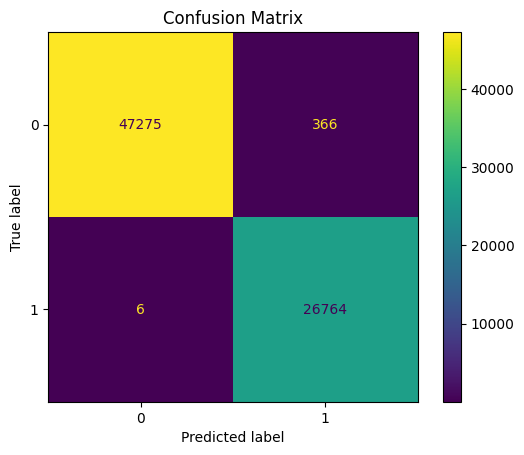

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [39]:
# 6) FAST + ACCURATE MODEL: ExtraTreesClassifier VS RandomForest



models = {
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),
}

fitted = {}
results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results.append((name, acc))
    fitted[name] = m

    print("\n==============================")
    print(f"{name} — Accuracy: {acc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification report:\n", classification_report(y_test, preds))

results_df = pd.DataFrame(results, columns=["model", "accuracy"]).sort_values("accuracy", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted[best_model_name]
print("\nBest model:", best_model_name)



ExtraTrees — Accuracy: 0.9951
Confusion matrix:
 [[47284   357]
 [    6 26764]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     47641
           1       0.99      1.00      0.99     26770

    accuracy                           1.00     74411
   macro avg       0.99      1.00      0.99     74411
weighted avg       1.00      1.00      1.00     74411


RandomForest — Accuracy: 0.9976
Confusion matrix:
 [[47466   175]
 [    2 26768]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     47641
           1       0.99      1.00      1.00     26770

    accuracy                           1.00     74411
   macro avg       1.00      1.00      1.00     74411
weighted avg       1.00      1.00      1.00     74411



,model,accuracy
1,RandomForest,0.997621
0,ExtraTrees,0.995122



Best model: RandomForest


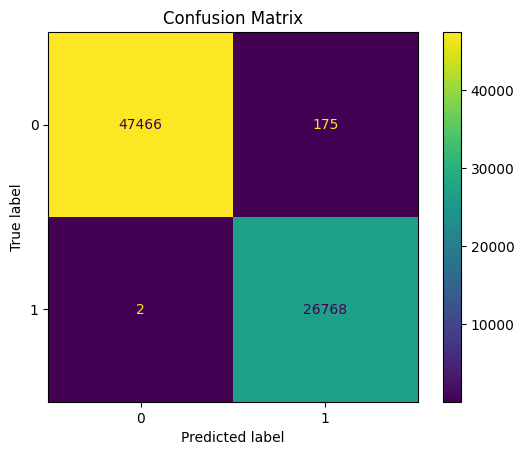

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [41]:
# from sklearn.metrics import mean_squared_error
# y_train_pred = reg.predict(X_train)
# mse = mean_squared_error(y_train, y_train_pred)
# print(mse)

In [42]:
# y_test_pred = reg.predict(X_test)
# mse = mean_squared_error(y_test, y_test_pred)
# print(mse)

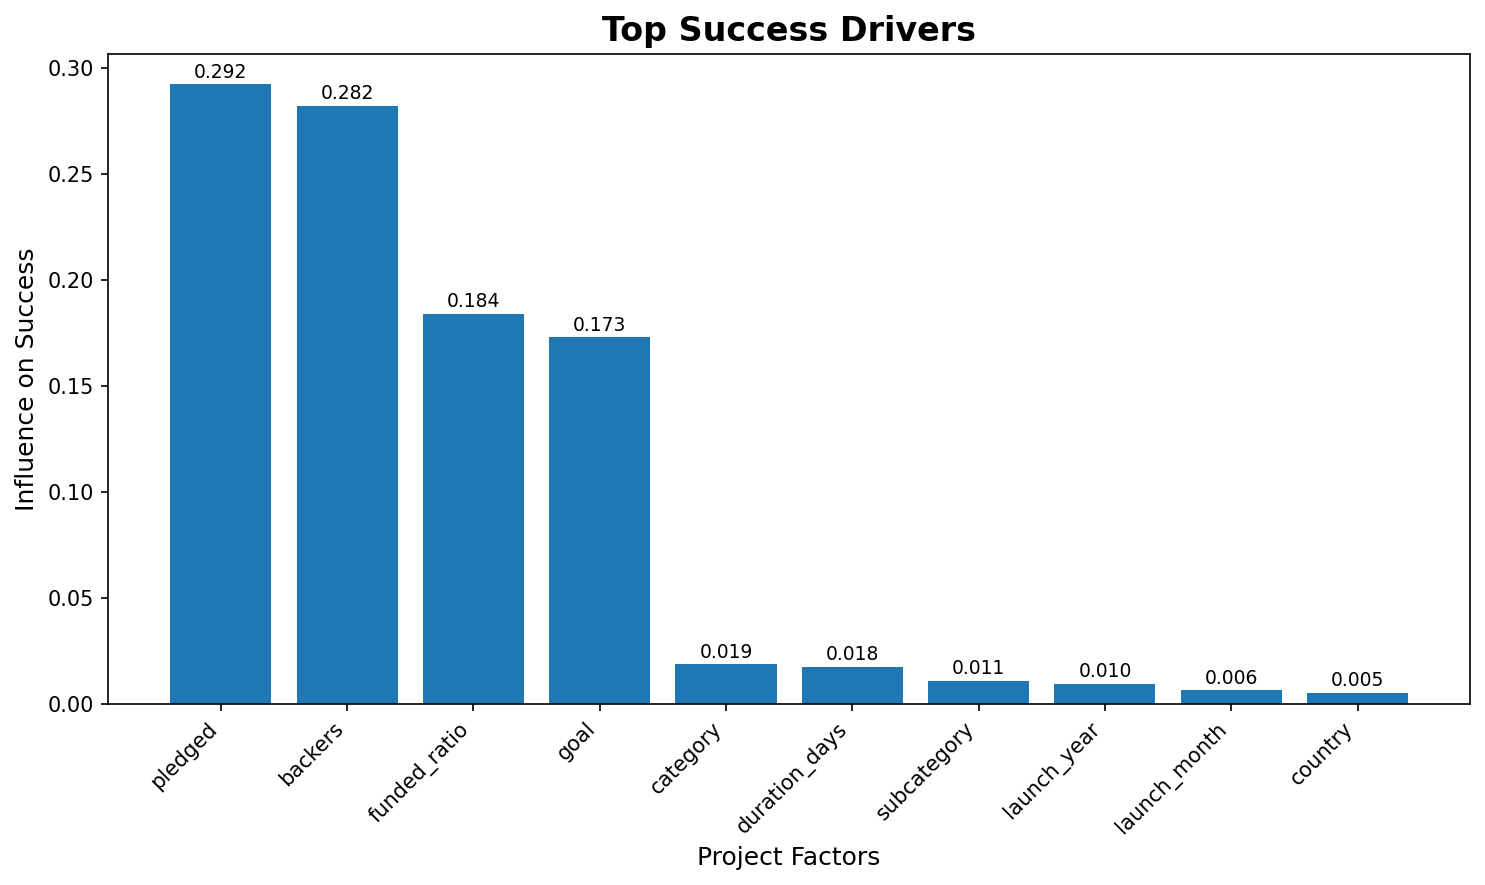

In [43]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# --- Select Top 10 ---
top_n = 10
top_features = X.columns[indices][:top_n]
top_importances = importances[indices][:top_n]

plt.figure(figsize=(10,6), dpi=150)

# Title (clean, corporate, non-technical)
plt.title("Top Success Drivers", fontsize=16, fontweight="bold")

# Vertical bars
plt.bar(range(top_n), top_importances, color="#1f77b4")

# X-axis labels
plt.xticks(
    range(top_n),
    top_features,
    rotation=45,
    ha="right",
    fontsize=10
)

# Axis labels
plt.xlabel("Project Factors", fontsize=12)
plt.ylabel("Influence on Success", fontsize=12)

# Add value labels above bars
for i, v in enumerate(top_importances):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [44]:
X.columns.shape
indices.shape
print(indices)

[4 5 7 3 0 6 1 8 9 2]


# COMPARE MODELS (ExtraTrees vs RandomForest vs XGBoost)

In [45]:
from sklearn.ensemble import  RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=80,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    )
}

results = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc}")

results

ExtraTrees: 0.9950007391380307
RandomForest: 0.9976213194285791
XGBoost: 0.997634758301864


{'ExtraTrees': 0.9950007391380307,
 'RandomForest': 0.9976213194285791,
 'XGBoost': 0.997634758301864}

#  HYPERPARAMETER TUNING (GridSearchCV)

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9944161476420644


# ROC Curve (for ExtraTrees or XGBoost)

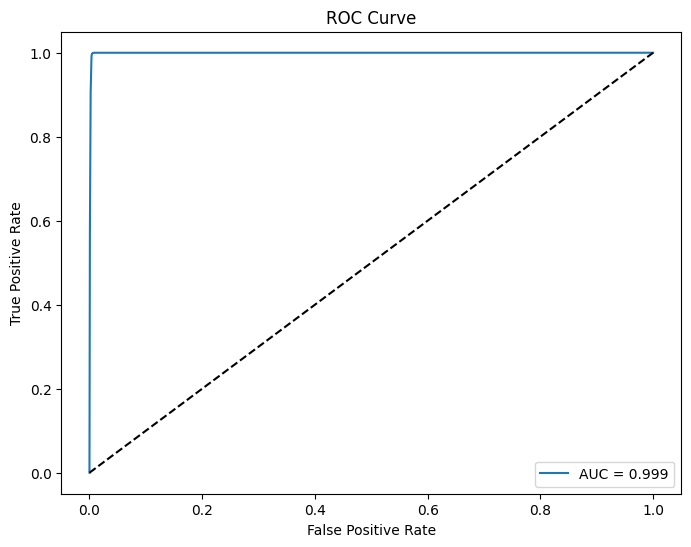

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# K-FOLD CROSS-VALIDATION (for ExtraTrees)

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X, y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross-Validation Scores: [0.61847039 0.99178885 0.92530674 0.99517544 0.9909422 ]
Mean CV Accuracy: 0.9043367244090253


In [49]:
import pickle

with open("kickstarter_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as kickstarter_model.pkl")

Model saved as kickstarter_model.pkl


In [50]:
with open("kickstarter_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

loaded_model.predict(X_test[:5])

array([1, 0, 0, 0, 1])

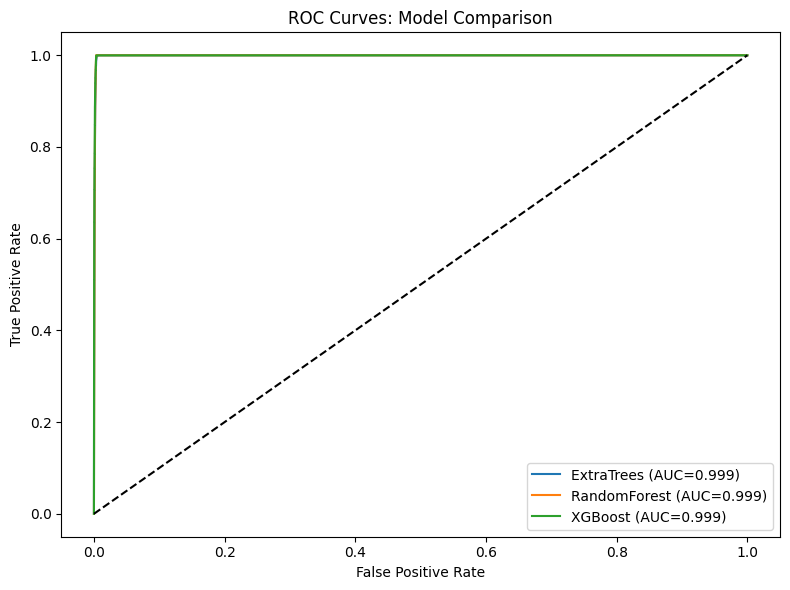

,Model,Accuracy,ROC_AUC
2,XGBoost,0.997621,0.999370
0,ExtraTrees,0.995068,0.999137
1,RandomForest,0.997635,0.999100


In [51]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# If XGBoost not installed: pip install xgboost
from xgboost import XGBClassifier

models = {
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=120,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=4,
        random_state=42
    )
}

results = []
plt.figure(figsize=(8,6))

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)

    # Probabilities for ROC-AUC
    proba = m.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    results.append((name, acc, auc))

    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curves: Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"]).sort_values("ROC_AUC", ascending=False)
results_df

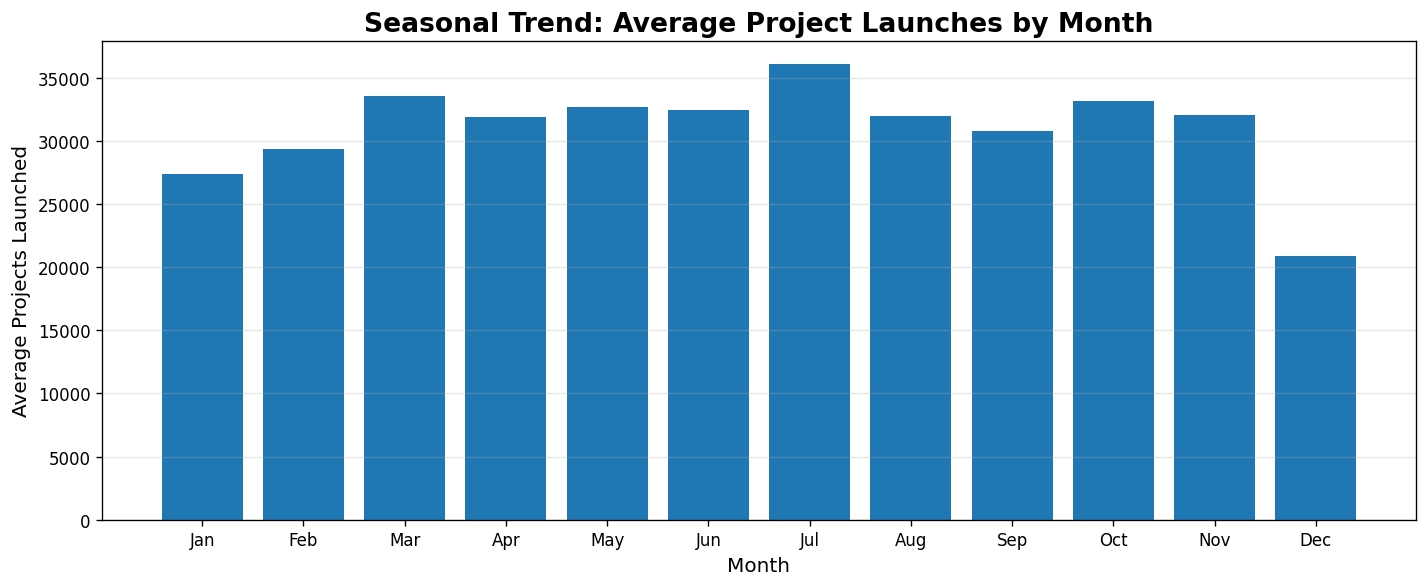

In [64]:
# E) Seasonal trend: Average launches by month

# Ensure datetime
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")

# Month name + month number for correct ordering
df["launch_month_num"] = df["launched"].dt.month
df["launch_month_name"] = df["launched"].dt.strftime("%b")  # Jan, Feb, ...

# Count projects per (year, month)
monthly_counts = (
    df.dropna(subset=["launched"])
      .groupby([df["launched"].dt.month, "launch_month_num", "launch_month_name"])
      .size()
      .reset_index(name="projects")
)

# Average across years for each month (seasonality)
seasonal = (
    monthly_counts.groupby(["launch_month_num", "launch_month_name"])["projects"]
    .mean()
    .reset_index()
    .sort_values("launch_month_num")
)

# Plot
plt.figure(figsize=(12,5), dpi=120)
plt.bar(seasonal["launch_month_name"], seasonal["projects"], color="#1f77b4")

plt.title("Seasonal Trend: Average Project Launches by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Projects Launched", fontsize=12)
plt.grid(axis="y", alpha=0.3)

#plt.tight_layout()

plt.tight_layout()
plt.show()

In [60]:
monthly_success_rate = df.groupby("launch_month")["is_success"].mean()
monthly_success_rate = monthly_success_rate.sort_index()

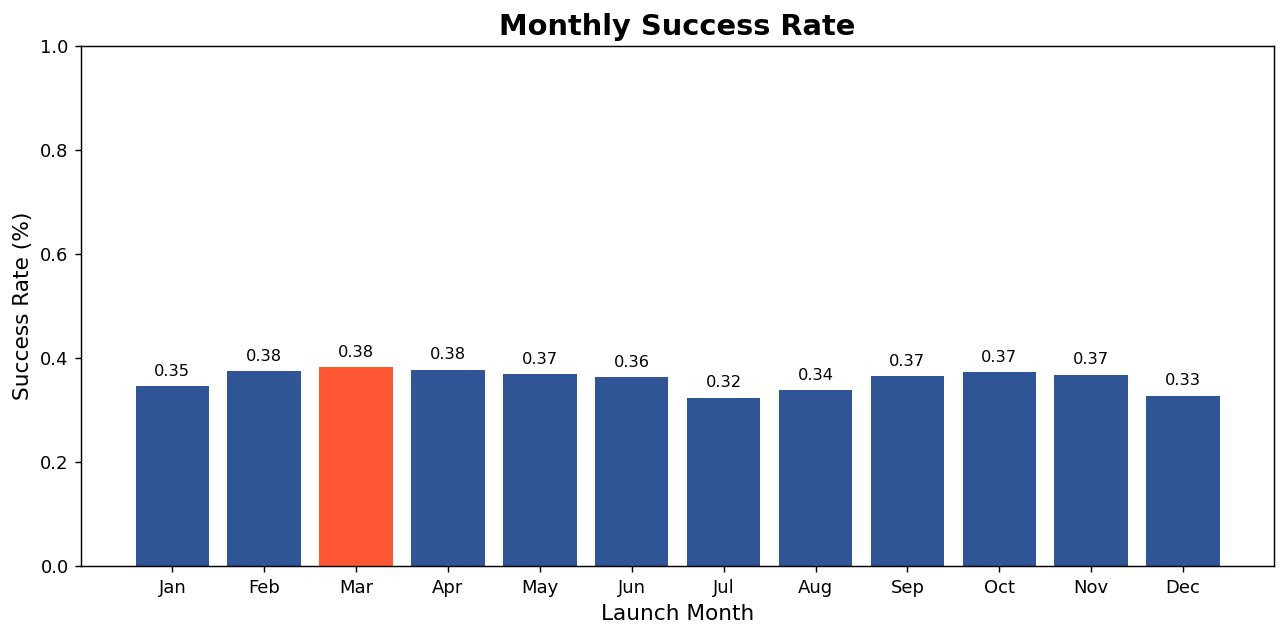

In [62]:
import matplotlib.pyplot as plt
dtf_perc = dtf_perc.sort_index()

# Identify the highest success rate month
max_value = dtf_perc.max()
max_month = dtf_perc.idxmax()
# Identify highest month
max_rate = monthly_success_rate.max()
max_month = monthly_success_rate.idxmax()

# Colors: highlight peak month in orange
colors = ["#2F5597" if m != max_month else "#FF5733" 
          for m in monthly_success_rate.index]

plt.figure(figsize=(10,5), dpi=130)

bars = plt.bar(
    monthly_success_rate.index,
    monthly_success_rate.values,
    color=colors
)

# Title & labels
plt.title("Monthly Success Rate", fontsize=16, fontweight="bold")
plt.xlabel("Launch Month", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 1)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

# Convert 1–12 to month names
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(monthly_success_rate.index, [month_names[i-1] for i in monthly_success_rate.index])

plt.tight_layout()
plt.show()

In [57]:
df["launch_month"] = df["launched"].dt.month
monthly_success_rate = df.groupby("launch_month")["is_success"].mean()
monthly_success_rate = monthly_success_rate.sort_index()

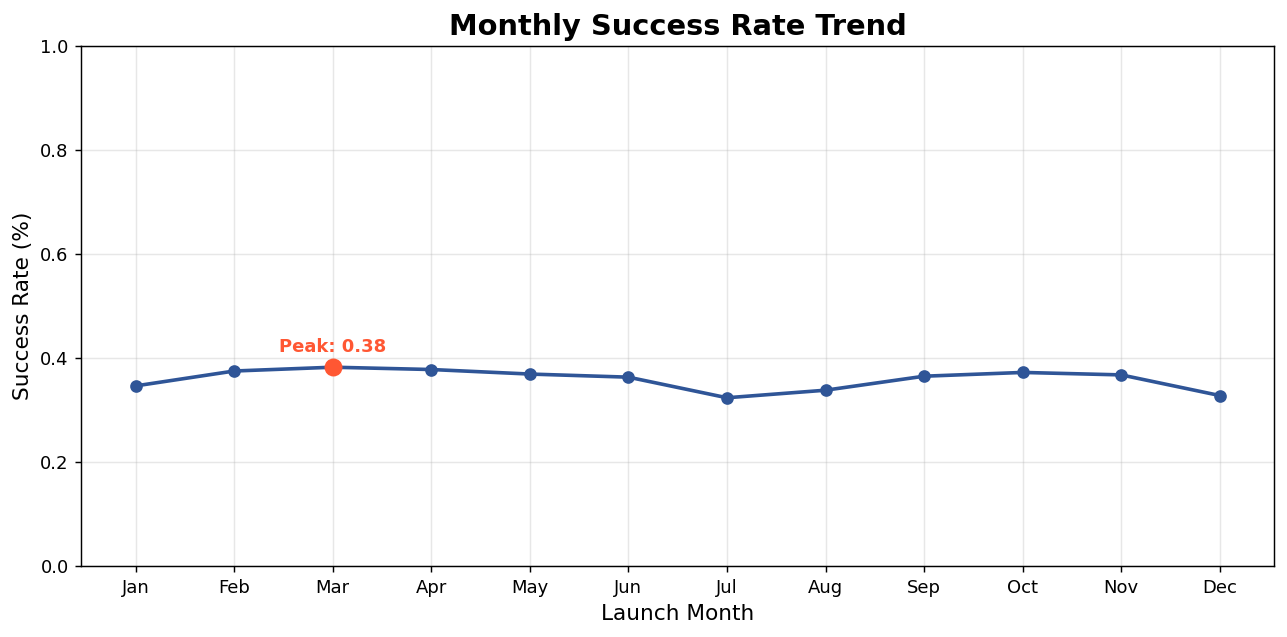

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5), dpi=130)

plt.plot(
    monthly_success_rate.index,
    monthly_success_rate.values,
    marker="o",
    linewidth=2,
    color="#2F5597"   # corporate deep blue
)

# Highlight highest month
max_m = monthly_success_rate.idxmax()
max_v = monthly_success_rate.max()

plt.scatter(max_m, max_v, color="#FF5733", s=80, zorder=5)
plt.text(
    max_m, max_v + 0.03,
    f"Peak: {max_v:.2f}",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#FF5733"
)

plt.title("Monthly Success Rate Trend", fontsize=16, fontweight="bold")
plt.xlabel("Launch Month", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 1)
plt.grid(alpha=0.3)

# Month names
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(monthly_success_rate.index, [month_names[i-1] for i in monthly_success_rate.index])

plt.tight_layout()
plt.show()